# IT4060 - HPC Failure Prediction

## Notebook: HistGradientBoostingClassifier

This notebook trains a histogram-based gradient boosting model using the processed multi-horizon feature table. The default target is `label_next_6h`, and the evaluation structure matches the earlier model notebooks so the later comparison step stays consistent.

In [1]:
from pathlib import Path
import os

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
PROJECT_NAME = 'IT4060-ML-Assignment-HPC-Failure-Prediction'
TARGET_COLUMN = 'label_next_6h'
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
LEARNING_RATE = 0.05
MAX_ITER = 200
MAX_DEPTH = 6
MAX_LEAF_NODES = 31
MIN_SAMPLES_LEAF = 50
L2_REGULARIZATION = 0.1
MODEL_VERBOSE = 1
RESULTS_MODEL_NAME = 'hist_gradient_boosting'

def find_project_root():
    cwd = Path.cwd().resolve()
    home = Path.home().resolve()
    desktop = home / 'Desktop'
    candidate_roots = [cwd, *cwd.parents, home, desktop, desktop / 'Manilka' / 'ML_Assignment']
    seen = set()

    for base in candidate_roots:
        for candidate in (base, base / PROJECT_NAME):
            if candidate in seen or not candidate.exists():
                continue
            seen.add(candidate)
            if (candidate / 'data' / 'processed').exists():
                return candidate

    raise FileNotFoundError('Could not locate the project root with data/processed.')

project_root = find_project_root()
processed_dir = project_root / 'data' / 'processed'
processed_path = processed_dir / 'node_hour_features_multi_horizon.csv.gz'
results_dir = project_root / 'results'
model_results_dir = results_dir / RESULTS_MODEL_NAME

if not processed_path.exists():
    raise FileNotFoundError('Processed feature table not found. Run 03_feature_engineering.ipynb first.')

model_results_dir.mkdir(parents=True, exist_ok=True)
overview_path = model_results_dir / 'overview.csv'
split_summary_path = model_results_dir / 'split_summary.csv'
run_metadata_path = model_results_dir / 'run_metadata.csv'
validation_metrics_path = model_results_dir / 'validation_metrics.csv'
validation_curve_path = model_results_dir / 'validation_threshold_curve.csv'
test_metrics_path = model_results_dir / 'test_metrics.csv'
test_risk_scores_path = model_results_dir / 'test_risk_scores.csv.gz'
top_risk_rows_path = model_results_dir / 'top_risk_rows.csv'
split_plot_path = model_results_dir / 'split_overview.png'
validation_plot_path = model_results_dir / 'validation_diagnostics.png'
test_plot_path = model_results_dir / 'test_evaluation.png'

print(f'Working directory: {Path.cwd()}')
print(f'Project root: {project_root}')
print(f'Processed data path: {processed_path}')
print(f'Results directory: {model_results_dir}')
print(f'Target column: {TARGET_COLUMN}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Max iterations: {MAX_ITER}')
print(f'Max depth: {MAX_DEPTH}')
print(f'Max leaf nodes: {MAX_LEAF_NODES}')
print(f'Min samples leaf: {MIN_SAMPLES_LEAF}')
print(f'L2 regularization: {L2_REGULARIZATION}')
print(f'Model verbose: {MODEL_VERBOSE}')
print(f"OMP_NUM_THREADS: {os.environ.get('OMP_NUM_THREADS')}")

Working directory: d:\_4TH_Year_2nd_Semester_Stuff\ML\Assignments\_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\notebooks
Project root: D:\_4TH_Year_2nd_Semester_Stuff\ML\Assignments\_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction
Processed data path: D:\_4TH_Year_2nd_Semester_Stuff\ML\Assignments\_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\data\processed\node_hour_features_multi_horizon.csv.gz
Results directory: D:\_4TH_Year_2nd_Semester_Stuff\ML\Assignments\_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\results\hist_gradient_boosting
Target column: label_next_6h
Learning rate: 0.05
Max iterations: 200
Max depth: 6
Max leaf nodes: 31
Min samples leaf: 50
L2 regularization: 0.1
Model verbose: 1
OMP_NUM_THREADS: 1


In [3]:
df = pd.read_csv(
    processed_path,
    parse_dates=['hour', 'next_failure_time'],
    low_memory=False,
)

target_columns = [column for column in df.columns if column.startswith('label_next_')]
feature_exclusions = ['hour', 'next_failure_time', 'hours_to_next_failure', *target_columns]
feature_columns = [column for column in df.columns if column not in feature_exclusions]

overview = pd.DataFrame([
    {'metric': 'Rows', 'value': len(df)},
    {'metric': 'Feature columns', 'value': len(feature_columns)},
    {'metric': 'Target positive count', 'value': int(df[TARGET_COLUMN].sum())},
    {'metric': 'Target positive rate', 'value': float(df[TARGET_COLUMN].mean())},
    {'metric': 'Hour range start', 'value': df['hour'].min()},
    {'metric': 'Hour range end', 'value': df['hour'].max()},
])

overview.to_csv(overview_path, index=False)

display(overview)
display(df[['node', 'hour', 'label_next_1h', 'label_next_6h', 'label_next_12h', 'label_next_24h']].head())

,metric,value
0,Rows,687814
1,Feature columns,34
2,Target positive count,701
3,Target positive rate,0.001019
4,Hour range start,2003-12-26 12:00:00
5,Hour range end,2005-10-21 20:00:00


,node,hour,label_next_1h,label_next_6h,label_next_12h,label_next_24h
0,0,2003-12-26 13:00:00,0,0,0,0
1,0,2003-12-26 14:00:00,0,0,0,0
2,0,2003-12-26 15:00:00,0,0,0,0
3,0,2003-12-26 19:00:00,0,0,0,0
4,0,2003-12-27 00:00:00,0,0,0,0


In [5]:
unique_hours = np.sort(df['hour'].unique())
train_end = int(len(unique_hours) * TRAIN_RATIO)
valid_end = int(len(unique_hours) * (TRAIN_RATIO + VALID_RATIO))

train_hours = unique_hours[:train_end]
valid_hours = unique_hours[train_end:valid_end]
test_hours = unique_hours[valid_end:]

train_df = df[df['hour'].isin(train_hours)].copy()
valid_df = df[df['hour'].isin(valid_hours)].copy()
test_df = df[df['hour'].isin(test_hours)].copy()

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'rows': len(train_df),
        'positives': int(train_df[TARGET_COLUMN].sum()),
        'positive_rate': float(train_df[TARGET_COLUMN].mean()),
        'start_hour': train_df['hour'].min(),
        'end_hour': train_df['hour'].max(),
    },
    {
        'split': 'validation',
        'rows': len(valid_df),
        'positives': int(valid_df[TARGET_COLUMN].sum()),
        'positive_rate': float(valid_df[TARGET_COLUMN].mean()),
        'start_hour': valid_df['hour'].min(),
        'end_hour': valid_df['hour'].max(),
    },
    {
        'split': 'test',
        'rows': len(test_df),
        'positives': int(test_df[TARGET_COLUMN].sum()),
        'positive_rate': float(test_df[TARGET_COLUMN].mean()),
        'start_hour': test_df['hour'].min(),
        'end_hour': test_df['hour'].max(),
    },
])

split_summary.to_csv(split_summary_path, index=False)

display(split_summary)

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET_COLUMN]
X_valid = valid_df[feature_columns].copy()
y_valid = valid_df[TARGET_COLUMN]
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET_COLUMN]

numeric_features = feature_columns
imputer = SimpleImputer(strategy='median')

X_train_model = X_train.copy()
X_valid_model = X_valid.copy()
X_test_model = X_test.copy()

X_train_model.loc[:, numeric_features] = imputer.fit_transform(X_train_model[numeric_features])
X_valid_model.loc[:, numeric_features] = imputer.transform(X_valid_model[numeric_features])
X_test_model.loc[:, numeric_features] = imputer.transform(X_test_model[numeric_features])

,split,rows,positives,positive_rate,start_hour,end_hour
0,train,488782,577,0.001180,2003-12-26 12:00:00,2005-04-08 16:00:00
1,validation,114395,76,0.000664,2005-04-08 17:00:00,2005-07-16 21:00:00
2,test,84637,48,0.000567,2005-07-16 22:00:00,2005-10-21 20:00:00


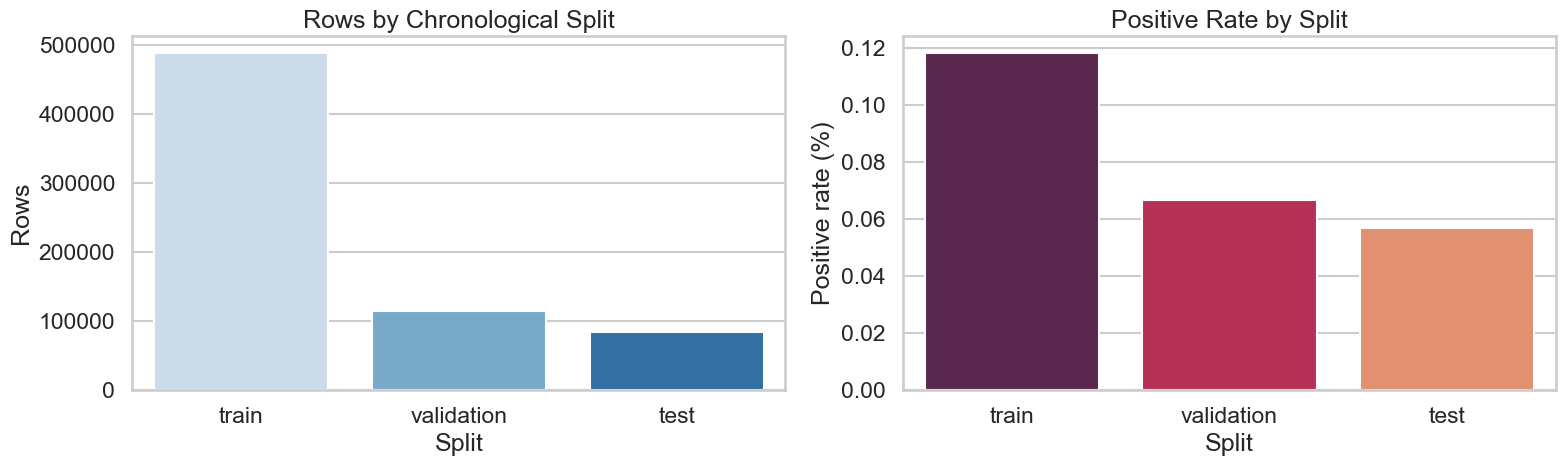

In [6]:
split_plot_df = split_summary.copy()
split_plot_df['positive_rate_percent'] = split_plot_df['positive_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=split_plot_df, x='split', y='rows', hue='split', dodge=False, legend=False, ax=axes[0], palette='Blues')
axes[0].set_title('Rows by Chronological Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Rows')

sns.barplot(data=split_plot_df, x='split', y='positive_rate_percent', hue='split', dodge=False, legend=False, ax=axes[1], palette='rocket')
axes[1].set_title('Positive Rate by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Positive rate (%)')

plt.tight_layout()
fig.savefig(split_plot_path, bbox_inches='tight')
plt.show()

In [7]:
model = HistGradientBoostingClassifier(
    loss='log_loss',
    learning_rate=LEARNING_RATE,
    max_iter=MAX_ITER,
    max_leaf_nodes=MAX_LEAF_NODES,
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    l2_regularization=L2_REGULARIZATION,
    early_stopping=False,
    class_weight='balanced',
    verbose=MODEL_VERBOSE,
    random_state=RANDOM_STATE,
)

model.fit(X_train_model, y_train)
print('HistGradientBoostingClassifier fitted successfully.')
print(f'Iterations completed: {model.n_iter_} / {MAX_ITER}')

run_metadata = pd.DataFrame([
    {
        'model_name': RESULTS_MODEL_NAME,
        'target_column': TARGET_COLUMN,
        'learning_rate': LEARNING_RATE,
        'max_iter': MAX_ITER,
        'max_depth': MAX_DEPTH,
        'max_leaf_nodes': MAX_LEAF_NODES,
        'min_samples_leaf': MIN_SAMPLES_LEAF,
        'l2_regularization': L2_REGULARIZATION,
        'iterations_completed': int(model.n_iter_),
        'train_rows': len(train_df),
        'validation_rows': len(valid_df),
        'test_rows': len(test_df),
        'train_positive_rate': float(y_train.mean()),
        'validation_positive_rate': float(y_valid.mean()),
        'test_positive_rate': float(y_test.mean()),
    }
])
run_metadata.to_csv(run_metadata_path, index=False)

Binning 0.133 GB of training data: 0.760 s
Fitting gradient boosted rounds:
Fit 200 trees in 40.000 s, (6110 total leaves)
Time spent computing histograms: 25.328s
Time spent finding best splits:  0.578s
Time spent applying splits:      4.833s
Time spent predicting:           0.344s
HistGradientBoostingClassifier fitted successfully.
Iterations completed: 200 / 200


In [8]:
def precision_at_k(y_true, scores, k=50):
    if len(scores) == 0:
        return np.nan
    k = min(k, len(scores))
    top_indices = np.argsort(scores)[::-1][:k]
    return float(np.asarray(y_true)[top_indices].mean())

def evaluate_scores(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)
    return {
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'predicted_positives': int(predictions.sum()),
        'precision_at_50': precision_at_k(y_true, scores, k=50),
    }

valid_scores = model.predict_proba(X_valid_model)[:, 1]
precision_curve, recall_curve, threshold_curve = precision_recall_curve(y_valid, valid_scores)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(precision_curve[:-1] + recall_curve[:-1], 1e-12, None)
best_threshold = float(threshold_curve[np.nanargmax(f1_curve)]) if len(threshold_curve) else 0.5

validation_results = pd.DataFrame([
    {'threshold': 0.50, **evaluate_scores(y_valid, valid_scores, 0.50)},
    {'threshold': best_threshold, **evaluate_scores(y_valid, valid_scores, best_threshold)},
])

validation_results.to_csv(validation_metrics_path, index=False)

display(validation_results)

,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.500000,0.00103,0.48273,0.000988,0.092105,0.001955,7085,0.0
1,0.832126,0.00103,0.48273,0.011858,0.039474,0.018237,253,0.0


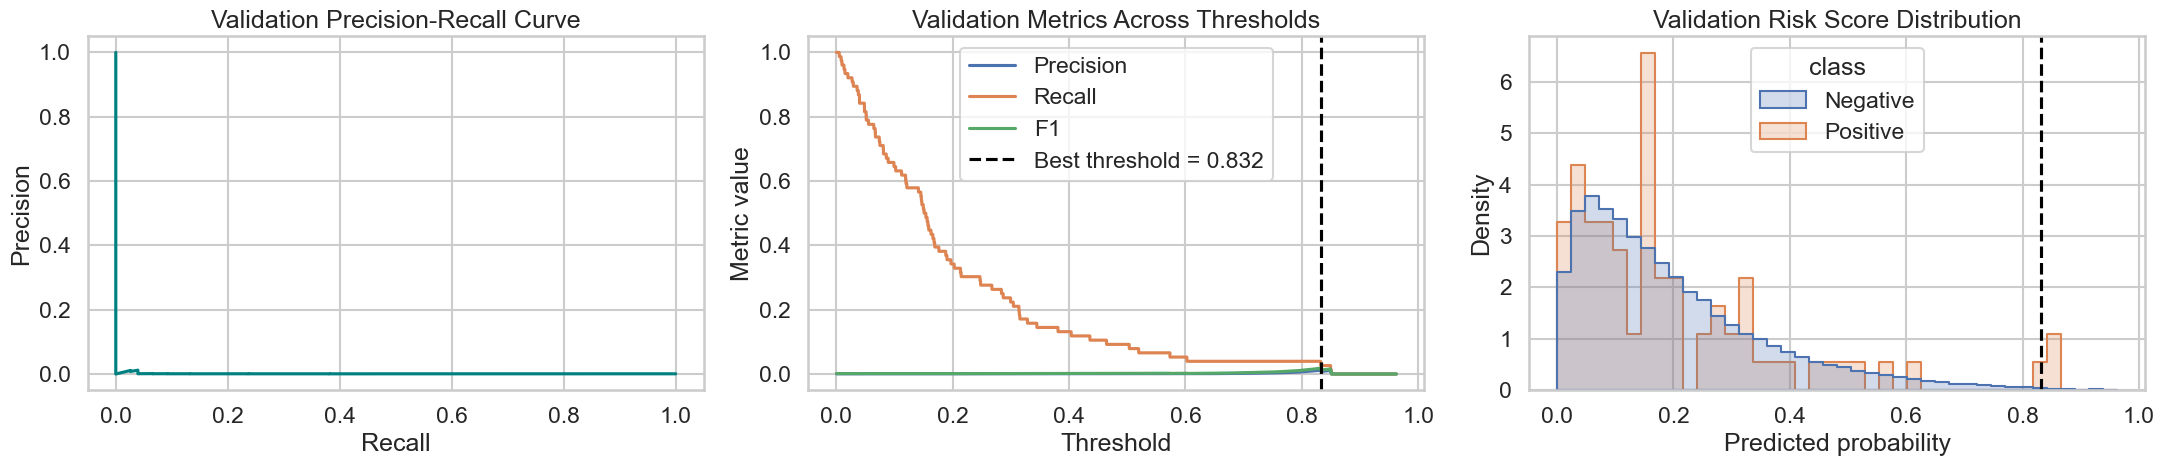

In [9]:
validation_curve_df = pd.DataFrame({
    'threshold': threshold_curve,
    'precision': precision_curve[:-1],
    'recall': recall_curve[:-1],
    'f1': f1_curve,
})

valid_plot_df = pd.DataFrame({
    'score': valid_scores,
    'class': np.where(y_valid.to_numpy() == 1, 'Positive', 'Negative'),
})

validation_curve_df.to_csv(validation_curve_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(recall_curve, precision_curve, color='teal')
axes[0].set_title('Validation Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

axes[1].plot(validation_curve_df['threshold'], validation_curve_df['precision'], label='Precision')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['recall'], label='Recall')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['f1'], label='F1')
axes[1].axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
axes[1].set_title('Validation Metrics Across Thresholds')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Metric value')
axes[1].legend()

sns.histplot(data=valid_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[2])
axes[2].axvline(best_threshold, color='black', linestyle='--')
axes[2].set_title('Validation Risk Score Distribution')
axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Density')

plt.tight_layout()
fig.savefig(validation_plot_path, bbox_inches='tight')
plt.show()

In [10]:
test_scores = model.predict_proba(X_test_model)[:, 1]
test_results = pd.DataFrame([
    {'threshold': 0.50, **evaluate_scores(y_test, test_scores, 0.50)},
    {'threshold': best_threshold, **evaluate_scores(y_test, test_scores, best_threshold)},
])

test_risk_scores = test_df[['node', 'hour', TARGET_COLUMN]].copy()
test_risk_scores['risk_score'] = test_scores
top_risk_rows = test_risk_scores.sort_values('risk_score', ascending=False).head(20)

test_results.to_csv(test_metrics_path, index=False)
test_risk_scores.to_csv(test_risk_scores_path, index=False, compression='gzip')
top_risk_rows.to_csv(top_risk_rows_path, index=False)

display(test_results)

display(top_risk_rows)

,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.500000,0.001257,0.552035,0.001187,0.125000,0.002352,5054,0.02
1,0.832126,0.001257,0.552035,0.004505,0.020833,0.007407,222,0.02


,node,hour,label_next_6h,risk_score
7274,0,2005-10-18 08:00:00,0,0.966029
6842,0,2005-08-30 06:00:00,0,0.965412
7204,0,2005-10-12 06:00:00,0,0.963810
6843,0,2005-08-30 09:00:00,0,0.959831
7263,0,2005-10-17 13:00:00,0,0.958216
6783,0,2005-08-23 07:00:00,0,0.958145
6719,0,2005-08-17 07:00:00,0,0.957302
6707,0,2005-08-16 07:00:00,0,0.954550
7273,0,2005-10-18 07:00:00,0,0.952952
6791,0,2005-08-24 09:00:00,0,0.952231


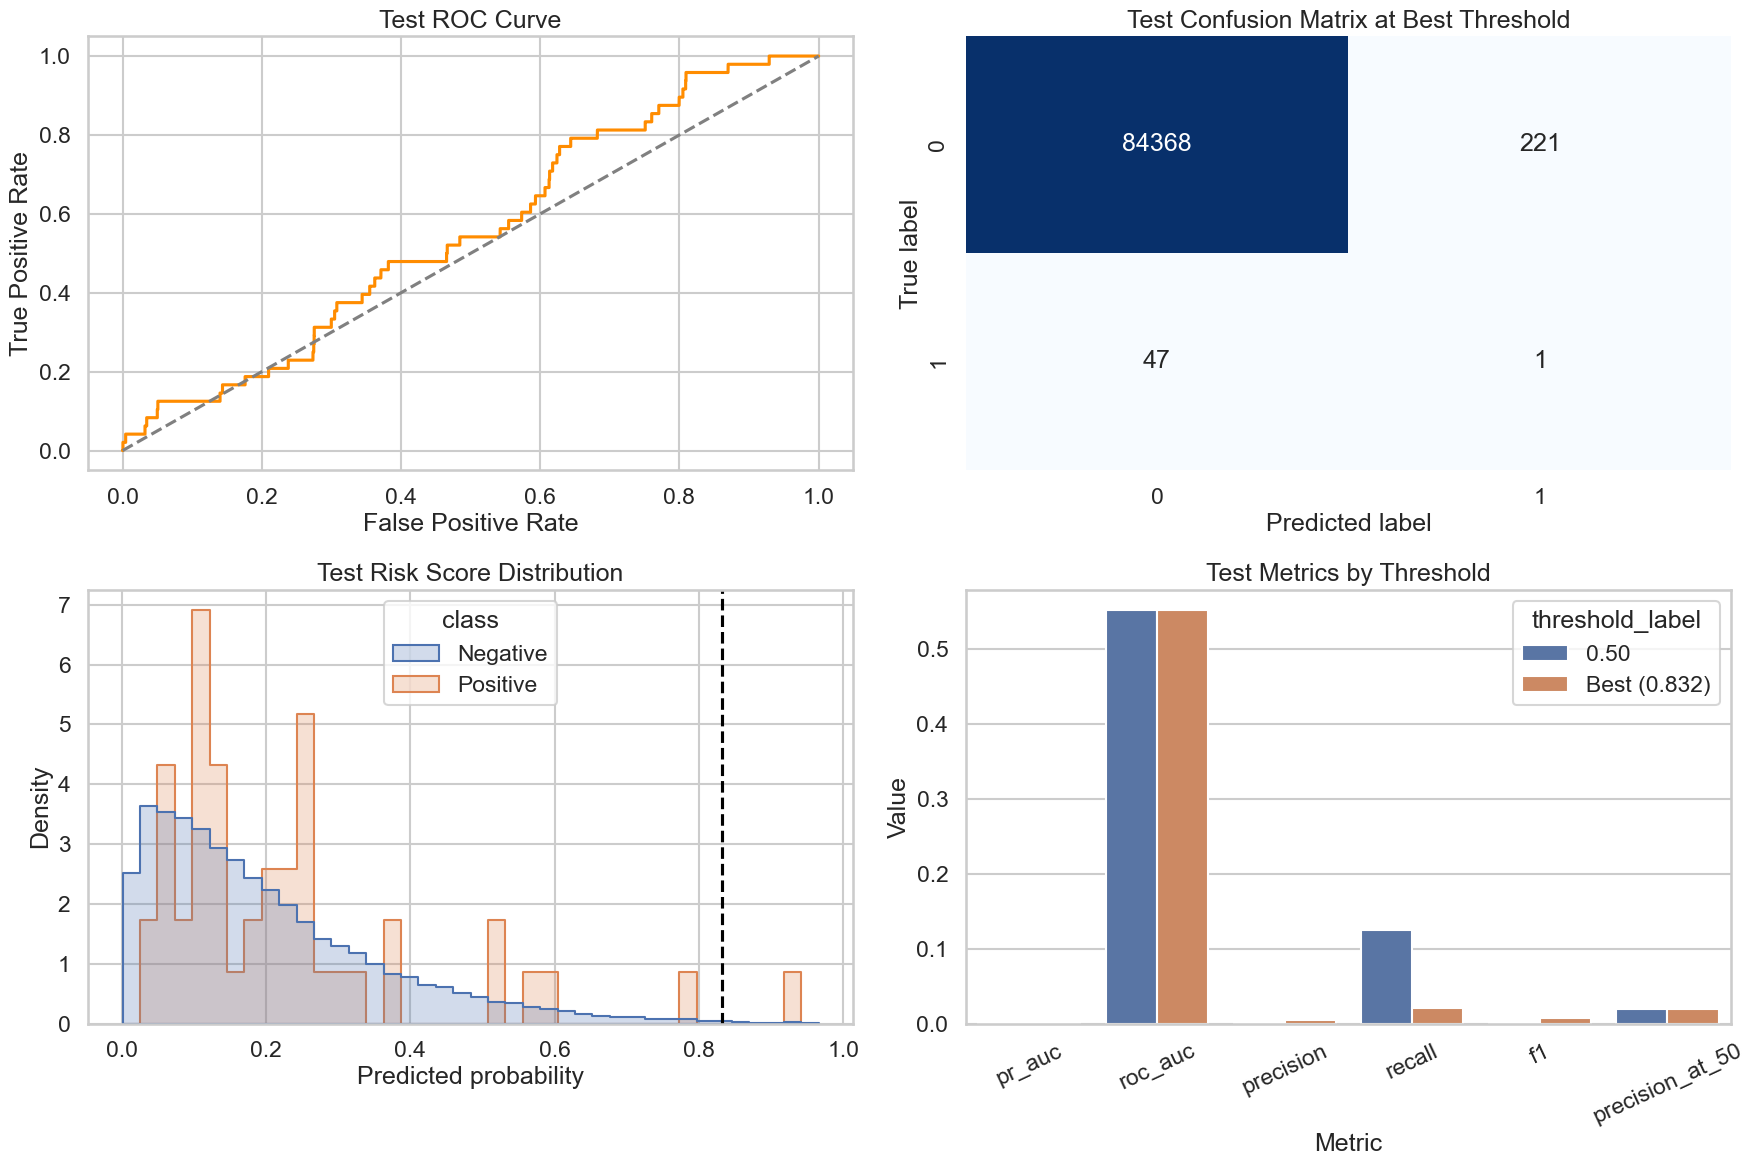

In [11]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
test_predictions_best = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions_best)

test_plot_df = pd.DataFrame({
    'score': test_scores,
    'class': np.where(y_test.to_numpy() == 1, 'Positive', 'Negative'),
})

metrics_plot_df = test_results.melt(
    id_vars='threshold',
    value_vars=['pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'precision_at_50'],
    var_name='metric',
    value_name='value',
)
metrics_plot_df['threshold_label'] = metrics_plot_df['threshold'].map(lambda value: '0.50' if value == 0.5 else f'Best ({value:.3f})')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0, 0].plot(fpr, tpr, color='darkorange')
axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 0].set_title('Test ROC Curve')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 1])
axes[0, 1].set_title('Test Confusion Matrix at Best Threshold')
axes[0, 1].set_xlabel('Predicted label')
axes[0, 1].set_ylabel('True label')

sns.histplot(data=test_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[1, 0])
axes[1, 0].axvline(best_threshold, color='black', linestyle='--')
axes[1, 0].set_title('Test Risk Score Distribution')
axes[1, 0].set_xlabel('Predicted probability')
axes[1, 0].set_ylabel('Density')

sns.barplot(data=metrics_plot_df, x='metric', y='value', hue='threshold_label', ax=axes[1, 1])
axes[1, 1].set_title('Test Metrics by Threshold')
axes[1, 1].set_xlabel('Metric')
axes[1, 1].set_ylabel('Value')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(test_plot_path, bbox_inches='tight')
plt.show()

## Summary

This notebook extends the modeling stage from [05_random_forest.ipynb](05_random_forest.ipynb) by testing a boosting-based model under the same chronological split and saved-results contract. HistGradientBoostingClassifier is a stronger tabular baseline for non-linear interactions, so its PR-AUC, ranking behavior, and threshold diagnostics should be compared directly against the logistic and random-forest notebooks.

Saved comparison artifacts for this run are written to `results/hist_gradient_boosting/`.